# Image Classification and Bounding Box Predictions

## 1. Prepare environment

In [2]:
# Importing libraries
import expectexception
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random
import torch
import torch.nn as nn
import PIL

from environment import prepare_environment
from typing import List
from operator import itemgetter
from torchvision import transforms
from torchvision.models import vgg16, VGG16_Weights
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.io import read_image
from torchvision.ops import nms, box_iou
from torchvision.utils import draw_bounding_boxes

In [3]:
# Check if your GPU driver and CUDA is enabled and accessible by PyTorch
print(torch.__version__)
print('Cuda is available?', torch.cuda.is_available())

2.4.1+cu124
Cuda is available? True


In [4]:
# Global variables
SEED = 42

GPU_DEVICE = torch.cuda.current_device() if torch.cuda.is_available() else None

DATASET_CATS_AND_DOGS_TRAIN = "data-sources/cats_and_dogs/training_set/"
DATASET_CATS_AND_DOGS_TEST = "data-sources/cats_and_dogs/test_set/"

ARTIFACTS_FOLDER = "artifacts/"

In [5]:
# Global configuration
prepare_environment()

torch.set_printoptions(precision=10)
torch.set_default_dtype(torch.float32)

# Reproducibility
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

In [6]:
def show_tensor_pil_image(image:[torch.Tensor, PIL.Image.Image],
                          title:str='Tensor Image',
                          figsize=(2, 2)) -> None:
    fig = plt.figure(figsize=figsize)
    plt.title(title)
    plt.axis('off')
    if type(image)==torch.Tensor:
        plt.imshow(image.permute(1, 2, 0))
        # if image.dtype == torch.float32
        #     plt.imshow(np.clip(image.permute(1, 2, 0), 0, 1))
        # else:
        #     plt.imshow(np.clip(image.permute(1, 2, 0), 0, 255))
    else:
        plt.imshow(image)
    plt.show()

## 2. Work with ssd300_vgg16

In [10]:
# Pretrained ssd300_vgg16(pretrained = True)
class PreTrainedBoundingBoxWithSsd300Vgg16:
    """A custom class to load the ssd300_vgg16 pretrained model to predict
    boundering box, score, and label.
    Only one [box, score, label] are retorned."""
    def __init__(self):
        # Step 1: Initialize model with the best available weights
        self.weights = SSD300_VGG16_Weights.DEFAULT
        self.categories = self.weights.meta["categories"]
        self.model = ssd300_vgg16(weights=self.weights)
        self.model.eval()

        # Step 2: Initialize the inference transforms
        self.preprocess = self.weights.transforms()

    def _predict(self, image_file):
        # Read the image
        self.original_image = read_image(image_file)

        # Step 3: Apply inference preprocessing transforms
        self.images = self.preprocess(self.original_image).unsqueeze(0)

        # Step 4: Use the model and print the predicted category
        with torch.no_grad():
            predictions = self.model(self.images)
        self.predictions = predictions
            
    def predict_one(self, image_file):
        self._predict(image_file)
        
        # As we only process one image:
        prediction = predictions[0]
        prediction = {'box': prediction['boxes'][0],  # First box
                      'score': prediction['scores'][0],  # First score
                      'label': self.categories[prediction['labels'][0]],
                      'image': self.images.squeeze(0),}  # First label
        return prediction

    def predict_all(self, image_file):
        self._predict(image_file)
        predictions = self.predictions.copy()
        for prediction, image in zip(self.predictions, self.images):
            prediction['image'] = image
            prediction['labels'] = [self.categories[label] for label in prediction['labels']]
        return predictions

### Read image and predict

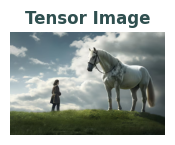

In [12]:
# Read image
image_file = "data-sources/channels-example/Campo.jpg"
image = read_image(image_file)
show_tensor_pil_image(image)

In [13]:
# Instantiate the model PreTrainedBoundingBoxWithSsd300Vgg16
boundingbox = PreTrainedBoundingBoxWithSsd300Vgg16()
boundings = boundingbox.predict_all(image_file)
boundings

[{'boxes': tensor([[301.5047607422,  64.1415557861, 590.4226074219, 326.0428161621],
          [159.3880462646, 193.6788787842, 206.8462371826, 322.1420898438],
          [415.2599487305, 212.9309844971, 566.4857788086, 327.3364562988],
          [163.7648773193, 263.7763671875, 193.6215667725, 317.9801330566],
          [357.7914733887, 208.5080108643, 486.6654357910, 320.6692810059],
          [479.1149597168, 194.2525787354, 601.4065551758, 320.7626953125],
          [174.8795928955, 285.0050048828, 201.9691009521, 323.4292907715],
          [163.9190521240, 249.1289520264, 191.3595581055, 295.0608520508],
          [160.6715240479, 277.9206848145, 211.6058197021, 325.0581359863],
          [447.7914428711, 221.7953948975, 519.2446899414, 314.0516357422],
          [130.2145385742, 131.5703125000, 134.9156494141, 135.0772399902],
          [387.6225891113, 216.6091461182, 452.0983276367, 316.6759033203],
          [146.4123535156, 131.9642028809, 151.1516723633, 135.6776733398],
   

In [14]:
for bounding in boundings:
    person_indices = [i for i, item in enumerate(bounding['labels']) if item == 'person']
    print('Total identified figures:', len(bounding['labels']))

Total identified figures: 200


Printing first 5 labels: ['horse', 'person', 'horse', 'person', 'horse']
Printing first 5 scores: tensor([0.9987993240, 0.9985210299, 0.0830424652, 0.0707628652, 0.0707004517])
Total objects with score>0.3: 2


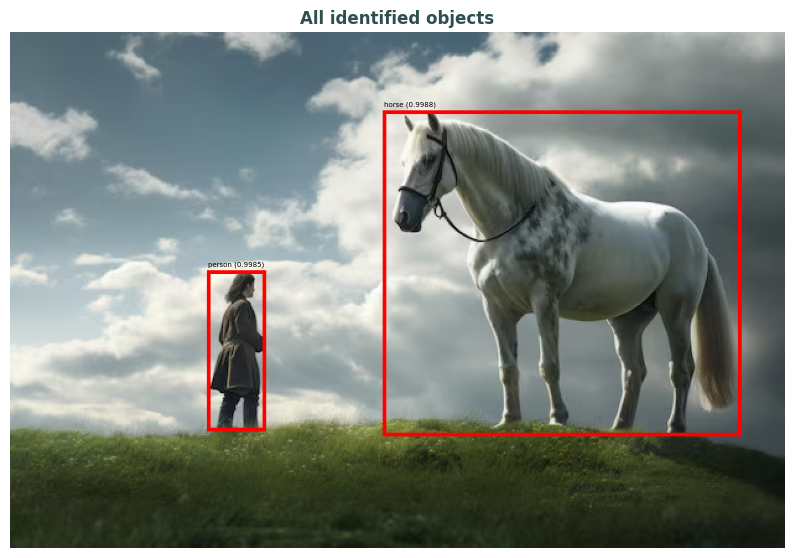

In [15]:
# Improving previous code
print('Printing first 5 labels:', bounding['labels'][:5])
print('Printing first 5 scores:', bounding['scores'][:5])

# Getting index of object with score>0.3
box_indices = (bounding['scores'] > 0.3).nonzero(as_tuple=False).flatten()
print('Total objects with score>0.3:', len(box_indices))

tensor_image = bounding['image'] # The last one is the only item

fig = plt.figure(figsize=(10, 10))
plt.title('All identified objects')
bbox_image = draw_bounding_boxes(tensor_image, bounding['boxes'][box_indices],
                                 width=3, colors="red")
plt.imshow(bbox_image.permute(1, 2, 0))
for box, label, score in zip(bounding['boxes'][box_indices],
                             itemgetter(*box_indices)(bounding['labels']),
                             bounding['scores'][box_indices]):
    plt.text(x=box[0].item(), y=box[1].item()-5,
             s=f"{label} ({score.item():.4f})", fontsize=5)
plt.axis('off')
plt.show()

---------------------------